In [1]:
DATASET_PATH = "../dataset/bigcodebench_normalized_filtered.json"
OUT_PATH      = "../results/bigcodebench_llm_clones.json" 
FILTERED_PATH = "../results/bigcodebench_llm_clones_filtered.json" 
FILTERED_CODEBLEU_PATH = "../results/bigcodebench_llm_clones_filtered_codebleu.json" 
FINAL_DATASET = "../results/bigcodebench_clone_dataset.json" 
codebleu_threshold = 0.4

# Mass spring

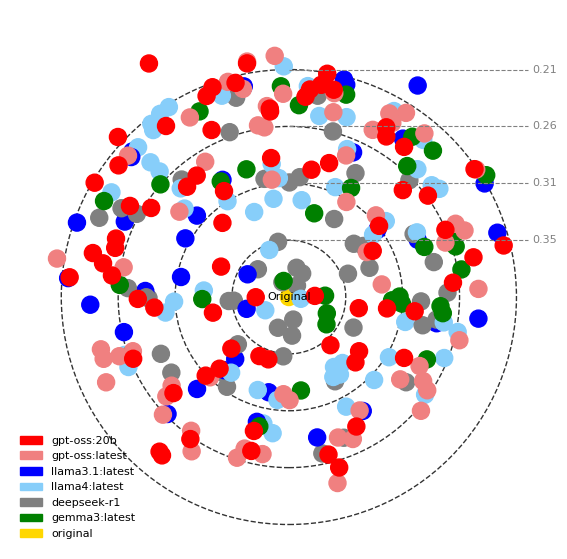

In [2]:
from src.mass_spring import plot_mass_spring_graph
import json
with open(FILTERED_CODEBLEU_PATH, "r") as f:
    data = json.load(f)
plot_mass_spring_graph(data, entry_index=5, color_by="model")
# plot_mass_spring_graph(data, entry_index=5, color_by="context")
# plot_mass_spring_graph(data, entry_index=5, color_by="strategy")
# plot_mass_spring_graph(data, entry_index=5, color_by="nfrs")

# Agg clustering

Saved clusters for entry BigCodeBench/0 in ../results/clustering/clusters\BigCodeBench/0
Saved all representatives for entry BigCodeBench/0 in ../results/clustering\representatives\BigCodeBench_0\BigCodeBench_0_representatives.py


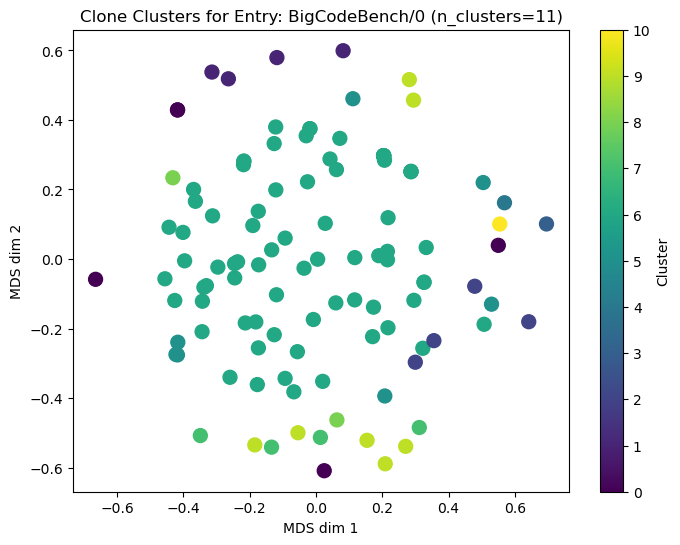

Saved clusters for entry BigCodeBench/1 in ../results/clustering/clusters\BigCodeBench/1
Saved all representatives for entry BigCodeBench/1 in ../results/clustering\representatives\BigCodeBench_1\BigCodeBench_1_representatives.py


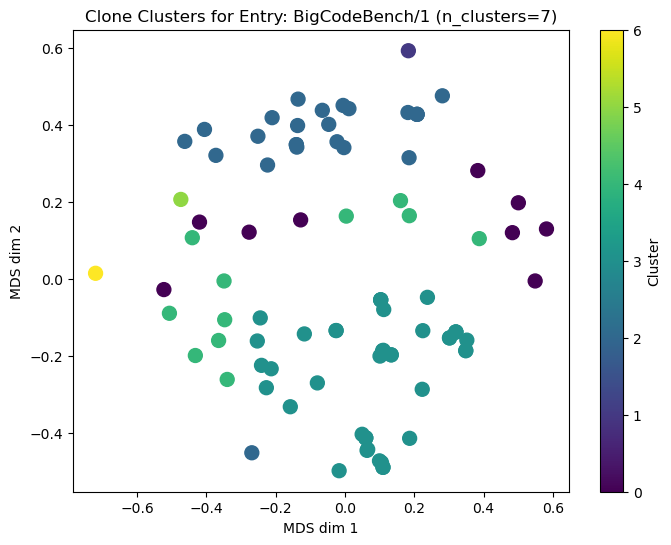

Saved clusters for entry BigCodeBench/2 in ../results/clustering/clusters\BigCodeBench/2
Saved all representatives for entry BigCodeBench/2 in ../results/clustering\representatives\BigCodeBench_2\BigCodeBench_2_representatives.py


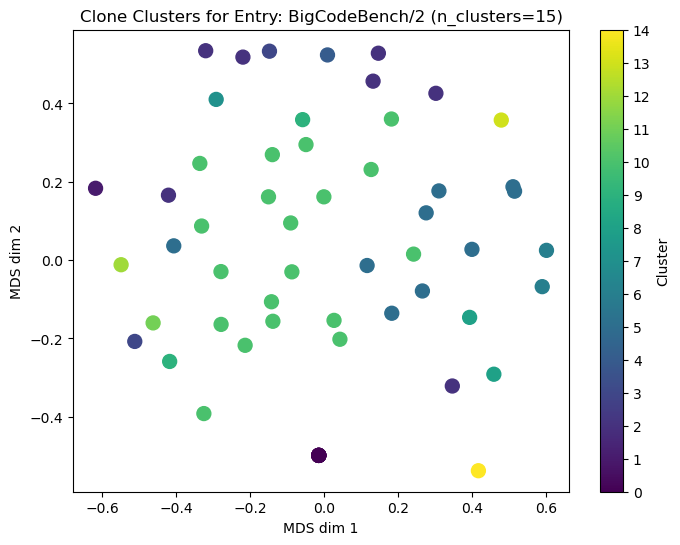

Saved clusters for entry BigCodeBench/3 in ../results/clustering/clusters\BigCodeBench/3
Saved all representatives for entry BigCodeBench/3 in ../results/clustering\representatives\BigCodeBench_3\BigCodeBench_3_representatives.py


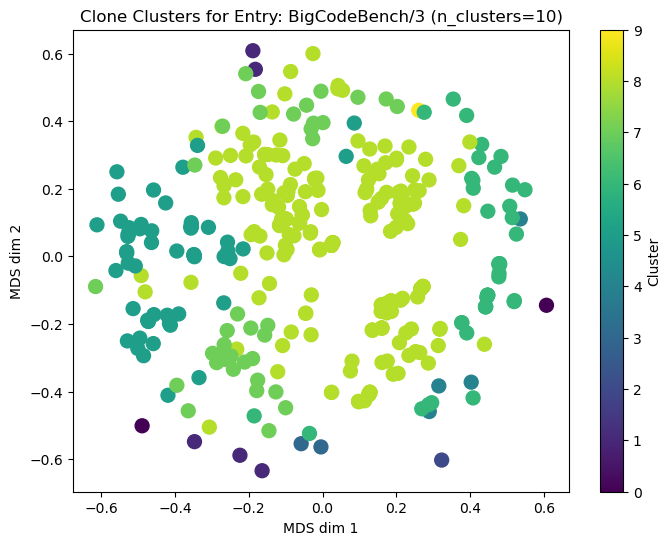

Saved clusters for entry BigCodeBench/4 in ../results/clustering/clusters\BigCodeBench/4
Saved all representatives for entry BigCodeBench/4 in ../results/clustering\representatives\BigCodeBench_4\BigCodeBench_4_representatives.py


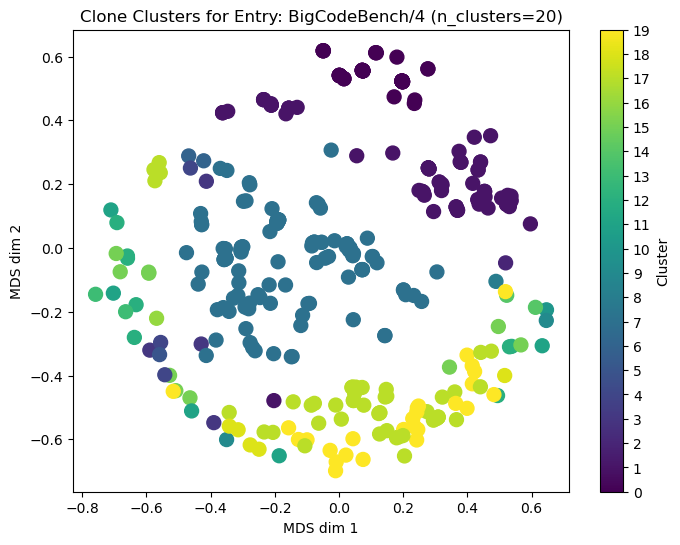

Saved clusters for entry BigCodeBench/5 in ../results/clustering/clusters\BigCodeBench/5
Saved all representatives for entry BigCodeBench/5 in ../results/clustering\representatives\BigCodeBench_5\BigCodeBench_5_representatives.py


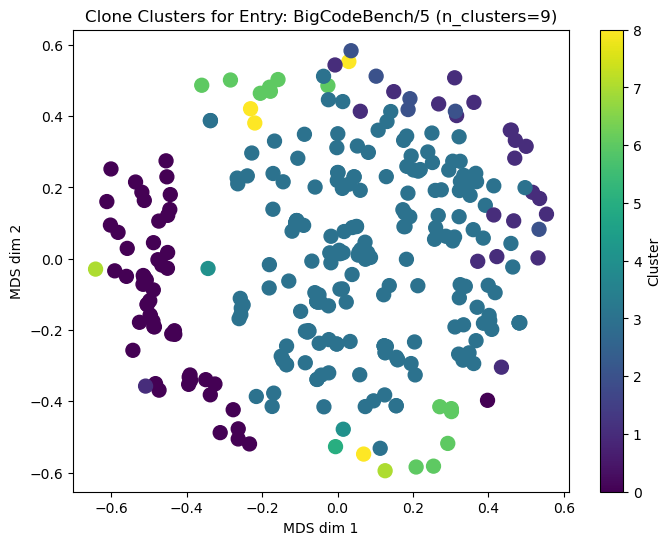

In [3]:
import json
from src.clustering import cluster_and_plot 

# Load the filtered data
with open(FILTERED_CODEBLEU_PATH, "r") as f:
    data = json.load(f)

# Cluster all entries
all_clusters = {}
for entry in data:
    entry_id = entry["id"]
    all_clusters[entry_id] = cluster_and_plot(entry, similarity_threshold=codebleu_threshold)

# Filter based on clusters

In [4]:
import os, json
from src.clustering import agg_cluster, select_representative_clones, build_affinity_matrix
from src.utils import extract_generated_fields, np_converter

# --- Load datasets ---
with open(FILTERED_CODEBLEU_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    complete_data = json.load(f)

# --- Build lookup ---
complete_lookup = {entry["id"]: entry for entry in complete_data}

merged_data = []

for idx, entry in enumerate(clone_data):
    clones = entry.get("clones", [])
    if not clones:
        print(f"⚠️ Entry {entry['id']} has no clones, skipping")
        continue

    affinity_matrix, clone_ids = build_affinity_matrix(entry) 

    # Cluster clones
    labels = agg_cluster(affinity_matrix, codebleu_threshold)
    if len(set(labels)) == 0:
        labels = [0] * n

    # Select representatives
    reps = select_representative_clones(entry, labels)
    if not reps:
        first_clone = clones[0]
        reps = [(0, first_clone["clone_id"], first_clone["code"])]

    # Build new clones list
    new_clones = []
    for cluster_label, cid, code in reps:
        orig_clone = next((c for c in clones if c["clone_id"] == cid), None)
        metrics = orig_clone.get("metrics", {}) if orig_clone else {}
        new_clones.append({
            "clone_id": cid,
            "model": orig_clone.get("model"),
            "strategy": orig_clone.get("strategy"),
            "context": orig_clone.get("context"),
            "nfrs": orig_clone.get("nfrs"),
            "cluster": cluster_label,
            "code": code
        })

    # Merge with complete dataset entry
    original_entry = complete_lookup.get(entry["id"], {})
    other_fields, generated_data = extract_generated_fields(original_entry)
    filtered_entry = other_fields.copy()
    filtered_entry["generated_data"] = generated_data
    filtered_entry["clones"] = new_clones

    merged_data.append(filtered_entry) 

os.makedirs(os.path.dirname(FINAL_DATASET), exist_ok=True)
with open(FINAL_DATASET, "w", encoding="utf-8") as f:
    json.dump(merged_data, f, indent=2, default=np_converter)

print(f"\n✅ New dataset with representatives saved to {FINAL_DATASET}, total entries: {len(merged_data)}")



✅ New dataset with representatives saved to ../results/bigcodebench_clone_dataset.json, total entries: 6
